# Pré-processing et modélisation : prédiction de la bactériémie

Ce notebook part des données brutes et va jusqu'au modèle enregistré. Il est en un seul morceau pour que la préparation ne soit jamais écrite deux fois.

Il produit trois choses :

1. la fonction `preparer()`, que `Predicts.py` réutilisera à l'identique ;
2. le découpage entraînement / test, enregistré sur disque ;
3. un modèle et son seuil de décision, enregistrés dans `models/`.

**Décisions issues de l'EDA**

| Constat | Décision |
|---|---|
| 27 % de lignes complètes | Aucune suppression de patients |
| Manquants par panel, mécanisme non MCAR | Un indicateur de manquant par variable |
| Valeurs impossibles (`HCT` à 0, potassium à 36,6) | Passées en `null` |
| 34 variables très asymétriques | Log, pour les modèles linéaires seulement |
| Classes à 8 % de positifs | Pondération des classes et réglage du seuil |

## 1. Importation des données

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier, StackingClassifier)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.metrics import confusion_matrix, roc_curve

from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     TunedThresholdClassifierCV,
                                     cross_val_predict, cross_validate,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from skopt.callbacks import DeltaYStopper

SEED = 42

- [Polars](https://docs.pola.rs)
- [Sklearn](https://scikit-learn.org/stable/api/sklearn.html#)

In [2]:
pl.Config.set_tbl_cols(-1)   # afficher toutes les colonnes
pl.Config.set_tbl_rows(20)


polars.config.Config

In [3]:
data = "../data/bacteriemie.csv.gz"

# null_values="NA" : sans cela polars echoue sur la premiere colonne numerique contenant NA
df = pl.read_csv(data, null_values="NA")
df.shape


(11753, 53)

In [4]:
df.head()


ID,SEX,AGE,MCV,HGB,HCT,PLT,MCH,MCHC,RDW,MPV,LYM,MONO,EOS,BASO,NT,APTT,FIB,SODIUM,POTASS,CA,PHOS,MG,CREA,BUN,HS,GBIL,TP,ALB,AMY,PAMY,LIP,CHE,AP,ASAT,ALAT,GGT,LDH,CK,GLU,TRIG,CHOL,CRP,BASOR,EOSR,LYMR,MONOR,NEU,NEUR,PDW,RBC,WBC,BloodCulture
i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1,2,62,99.3,11.5,35.9,307,31.5,31.8,19.5,10.8,0.4,1.7,0.0,0.1,86,28.8,578,137,3.88,2.29,1.2,0.66,0.65,5.7,5.3,0.59,67.0,36.7,30,16,10,5.12,85,22,14,48,284,23,107,105,175,3.94,0.413223,0.0,1.652893,7.024793,22.0,90.909091,10.6,3.7,24.1,"""no"""
3,1,72,85.1,10.3,34.7,182,26.0,30.6,15.0,9.7,0.4,0.2,0.1,0.0,90,29.8,null,141,null,2.21,0.58,null,0.76,19.9,null,0.48,65.3,37.4,null,null,null,5.61,80,28,25,61,null,36,84,null,null,1.42,0.0,0.826446,3.305785,1.652893,11.4,94.214876,11.4,3.9,12.17,"""no"""
5,1,46,96.3,7.4,22.8,64,31.2,32.4,19.7,11.1,1.5,1.2,0.1,0.1,58,36.3,313,147,4.61,1.92,1.51,1.03,1.25,50.6,null,8.42,40.5,22.1,146,null,89,2.52,119,124,135,134,696,40,107,null,null,12.09,0.568182,0.568182,8.522727,6.818182,14.7,83.522727,14.1,2.5,17.45,"""no"""
9,2,38,85.1,13.7,38.7,183,30.2,35.3,12.6,10.0,0.8,0.4,0.0,0.0,95,33.1,490,137,null,2.34,0.97,0.74,0.65,8.5,3.0,0.42,78.4,43.8,84,50,50,6.91,108,35,22,72,null,79,93,152,167,11.17,0.0,0.0,8.333333,4.166667,8.4,87.5,12.2,4.4,9.86,"""no"""
10,1,68,104.5,15.7,46.9,144,34.8,33.5,13.9,10.9,2.2,0.9,0.1,0.0,61,41.8,400,141,4.41,2.08,0.99,0.56,0.82,15.3,5.5,2.4,57.5,30.1,95,57,25,6.79,68,32,11,68,263,75,89,85,144,5.89,0.0,1.0,22.0,9.0,6.8,68.0,12.9,4.3,9.94,"""no"""


***Recodage de la cible***

`BloodCulture` est fournie en texte (`no` / `yes`). `replace_strict` lève une erreur si une modalité inattendue apparaît, ce qui est préférable à un recodage silencieux sur le jeu de test.

In [5]:
df = df.with_columns(
    pl.col("BloodCulture").replace_strict({"no": 0, "yes": 1}).cast(pl.Int8)
)

df["BloodCulture"].value_counts().sort("BloodCulture")


BloodCulture,count
i8,u32
0,10809
1,944


## 2. Nettoyage des valeurs impossibles

***Les quatre règles, issues de l'EDA***

| Règle | Justification |
|---|---|
| `HCT` ≤ 1 | Un hématocrite nul est impossible chez un patient dont l'hémoglobine est normale |
| `PLT` = 0 | Idem pour les plaquettes |
| `WBC` = 0 | Une absence totale de globules blancs n'est pas compatible avec la vie |
| `POTASS` > 10 | Au-delà de 10 mmol/L, il s'agit presque toujours d'une hémolyse du prélèvement |

On remplace par `null` plutôt que de supprimer la ligne : le patient garde ses autres analyses.

In [6]:
def nettoyer(df: pl.DataFrame) -> pl.DataFrame:
    """Remplace les valeurs physiologiquement impossibles par des valeurs manquantes."""
    return df.with_columns(
        HCT=pl.when(pl.col("HCT") <= 1).then(None).otherwise(pl.col("HCT")),
        PLT=pl.when(pl.col("PLT") == 0).then(None).otherwise(pl.col("PLT")),
        WBC=pl.when(pl.col("WBC") == 0).then(None).otherwise(pl.col("WBC")),
        POTASS=pl.when(pl.col("POTASS") > 10).then(None).otherwise(pl.col("POTASS")),
    )

In [7]:
# # Controle : combien de valeurs ont ete converties en null ?
# suivi = ["HCT", "PLT", "WBC", "POTASS"]

# pl.concat([
#     df.select(suivi).null_count().with_columns(etape=pl.lit("avant")),
#     nettoyer(df).select(suivi).null_count().with_columns(etape=pl.lit("apres")),
# ])


***Les indices erythrocytaires reparent leurs sources***

`MCV`, `MCH` et `MCHC` sont calcules depuis `RBC`, `HGB` et `HCT`, donc redondants : ils sont deja ecartes par `REDONDANTES`. Mais avant de les ecarter, ils servent une derniere fois.

**Le constat** : quand un indice manque, ses sources manquent aussi. Les 37 lignes concernees sont des bilans hematologiques entierement absents, pas des trous isoles. Recalculer les indices manquants ne recupererait donc rien. En sens inverse, en revanche, 338 `RBC` sur 375 et 21 `HCT` sur 58 sont reconstructibles.

**La fidelite** : erreur relative mediane de 2,02 % pour `RBC` et 0,69 % pour `HCT`, contre 14,71 % et 13,53 % pour une imputation par la mediane. Sept fois plus precis, malgre le bruit d'anonymisation applique separement a chaque colonne.

**Les pourcentages leucocytaires ne beneficient pas du meme traitement** : aucune de leurs sources n'est reconstructible, car `WBC` et les comptes absolus manquent exactement quand les pourcentages manquent. Pour eux, la redondance est totale et la suppression seche.


In [8]:
def reparer_sources(df: pl.DataFrame) -> pl.DataFrame:
    """Reconstruit RBC et HCT depuis les indices erythrocytaires, avant leur retrait.

    MCH  = HGB / RBC x 10   ->  RBC = HGB / MCH x 10
    MCHC = HGB / HCT x 100  ->  HCT = HGB / MCHC x 100

    MCV + HCT reconstruit 317 RBC, tous inclus dans les 338 de MCH + HGB :
    une seule formule suffit. Les pourcentages leucocytaires ne reparent rien.
    """
    return df.with_columns(
        RBC=pl.coalesce(pl.col("RBC"), pl.col("HGB") / pl.col("MCH") * 10),
        HCT=pl.coalesce(pl.col("HCT"), pl.col("HGB") / pl.col("MCHC") * 100),
        # 375 RBC nuls dont 338 réparables par HGB/MCH
        # 58 HCT nuls dont 21 réparables par HGB/MCH
    )


In [9]:
# Controle : combien de valeurs ont ete reconstruites ?
avant = nettoyer(df)
apres = reparer_sources(avant)

pl.DataFrame({
    "variable": ["RBC", "HCT"],
    "nuls_avant": [avant[c].null_count() for c in ("RBC", "HCT")],
    "nuls_apres": [apres[c].null_count() for c in ("RBC", "HCT")],
})


variable,nuls_avant,nuls_apres
str,i64,i64
"""RBC""",375,37
"""HCT""",58,37


## 3. Variables construites

***L'absence d'une analyse est informative***

Qu'une analyse soit absente n'est pas neutre : soit le médecin ne l'a pas jugée utile, soit l'automate n'a pas pu la rendre. Imputer sans le signaler effacerait cette information.

C'est le rôle de `add_indicator=True` dans l'imputation, plus bas : il crée une colonne binaire par variable manquante.

***Compte de défaillances d'organe***

Six critères, un par système, sur le modèle des scores de gravité hospitaliers.

**L'idée** : plutôt que de juger chaque analyse séparément, on compte combien de systèmes vont mal. Chaque critère franchi vaut 1, on les additionne, et le patient reçoit une note de 0 à 6.

**Pourquoi cela a du sens ici** : une infection localisée touche un organe, une bactériémie se répand et en touche plusieurs. Le compte capte donc cette dimension générale, qu'aucune analyse isolée ne traduit.

**Attention** : un nombre élevé n'affirme pas la bactériémie, il signale un risque plus grand. Seule l'hémoculture tranche.

In [10]:
# Derivees exactes de HGB, HCT et RBC. Elles servent d'abord a reparer leurs
# sources, puis sont retirees des donnees : une fois cette information recuperee,
# elles ne portent plus rien que leurs sources ne disent deja.
DERIVEES = ["MCV", "MCH", "MCHC"]

# Pourcentages leucocytaires : chacun vaut compte absolu / WBC x 100, et leur somme
# fait exactement 100. Cette dependance lineaire parfaite interdit de tous les donner
# a une regression. Ils sont donc ecartes du modele lineaire seul : les arbres,
# insensibles a la colinearite, les gardent.
REDONDANTES_LINEAIRE = ["BASOR", "EOSR", "LYMR", "MONOR", "NEUR"]


def _ratio(num: str, den: str) -> pl.Expr:
    """Rapport num/den, laisse null si le denominateur est nul ou absent."""
    return pl.when(pl.col(den) > 0).then(pl.col(num) / pl.col(den)).otherwise(None)


def ajouter_variables(df: pl.DataFrame) -> pl.DataFrame:
    """Compte de defaillances d'organe et rapports cliniques."""
    return df.with_columns(
        nb_anomalies=pl.sum_horizontal([
            (pl.col("PLT") < 150).cast(pl.Int8),        # plaquettes
            (pl.col("CREA") > 1.3).cast(pl.Int8),       # rein
            (pl.col("GBIL") > 1.2).cast(pl.Int8),       # foie
            (pl.col("NT") < 70).cast(pl.Int8),          # coagulation
            (pl.col("ALB") < 35).cast(pl.Int8),         # inflammation
            (pl.col("LYM") < 1).cast(pl.Int8),          # immunite
        ]),
        ratio_neu_lym=_ratio("NEU", "LYM"),      # marqueur d'infection bacterienne
        ratio_plt_lym=_ratio("PLT", "LYM"),      # inflammation systemique
        ratio_crp_alb=_ratio("CRP", "ALB"),      # inflammation contre denutrition
        ratio_bun_crea=_ratio("BUN", "CREA"),    # origine renale ou pre-renale
    )

***La fonction unique***

`preparer()` enchaîne le nettoyage et les variables construites. **C'est la seule fonction que `Predicts.py` devra reproduire**, ce qui garantit que le jeu de test subira le même traitement.

Elle ne contient aucun calcul appris sur les données : pas de médiane, pas de moyenne. Ces calculs restent dans le `ColumnTransformer`, donc appris sur l'entraînement seulement.

In [11]:
def preparer(df: pl.DataFrame) -> pl.DataFrame:
    """Nettoyage, reparation des sources, retrait des derivees, variables construites.

    L'ordre est impose : reparer_sources a besoin des derivees, donc le retrait
    vient apres. Et nettoyer vient avant tout, car pl.coalesce ne remplit que les
    null : sans nettoyage, un HCT aberrant resterait une valeur presente.

    Aucun calcul appris sur les donnees.
    """
    return ajouter_variables(reparer_sources(nettoyer(df)).drop(DERIVEES))


prep = preparer(df)
print("colonnes :", df.width, "->", prep.width)
prep.select("nb_anomalies").head()

colonnes : 53 -> 55


nb_anomalies
i8
1
1
4
1
4


In [12]:
prep.glimpse()

Rows: 11753
Columns: 55
$ ID             <i64> 1, 3, 5, 9, 10, 12, 19, 21, 23, 25
$ SEX            <i64> 2, 1, 1, 2, 1, 1, 2, 1, 2, 2
$ AGE            <i64> 62, 72, 46, 38, 68, 55, 52, 47, 59, 51
$ HGB            <f64> 11.5, 10.3, 7.4, 13.7, 15.7, 10.8, 10.3, 9.1, 10.0, 8.8
$ HCT            <f64> 35.9, 34.7, 22.8, 38.7, 46.9, 34.8, 30.1, 28.0, 31.0, 25.6
$ PLT            <i64> 307, 182, 64, 183, 144, 38, 105, 216, 92, 20
$ RDW            <f64> 19.5, 15.0, 19.7, 12.6, 13.9, 16.8, 13.2, 15.7, 19.7, 15.1
$ MPV            <f64> 10.8, 9.7, 11.1, 10.0, 10.9, null, 11.3, 10.9, 11.2, 9.6
$ LYM            <f64> 0.4, 0.4, 1.5, 0.8, 2.2, 0.4, 0.9, 0.7, 0.9, 0.2
$ MONO           <f64> 1.7, 0.2, 1.2, 0.4, 0.9, 0.1, 0.9, 0.6, 0.3, 0.1
$ EOS            <f64> 0.0, 0.1, 0.1, 0.0, 0.1, 0.1, 0.3, 0.0, 0.0, 0.0
$ BASO           <f64> 0.1, 0.0, 0.1, 0.0, 0.0, 0.0, 0.1, 0.1, 0.0, 0.0
$ NT             <i64> 86, 90, 58, 95, 61, 93, 69, 108, 93, 83
$ APTT           <f64> 28.8, 29.8, 36.3, 33.1, 41.8, 36.3, 28.

## 4. Partitionner les données

Attention au **data leakage** : une information issue du jeu de test ne doit jamais influencer l'entraînement.

Conséquences pratiques :

- le découpage se fait **avant** tout calcul de médiane, de moyenne ou de sélection de variables ;
- le jeu de test ne sert qu'une fois, à la toute fin ;
- les médianes d'imputation et les moyennes de standardisation s'apprennent dans le pipeline, sur l'entraînement.

***Features ($X$)***

`ID` est un identifiant, il n'a aucun pouvoir prédictif. Il faudra néanmoins le conserver dans `Predicts.py` pour le fichier de rendu.

In [13]:
X = prep.select(pl.exclude("ID", "BloodCulture"))
X.shape


(11753, 53)

***Outcome ($y$)***

In [14]:
y = prep["BloodCulture"]

pl.DataFrame({
    "classe": ["0 = pas de bacteriemie", "1 = bacteriemie"],
    "patients": [int((y == 0).sum()), int((y == 1).sum())],
    "part_%": [round((y == 0).mean() * 100, 2), round((y == 1).mean() * 100, 2)],
})


classe,patients,part_%
str,i64,f64
"""0 = pas de bacteriemie""",10809,91.97
"""1 = bacteriemie""",944,8.03


***Train test split***

Le découpage est **stratifié** : avec 8 % de positifs seulement, un tirage au hasard pourrait déséquilibrer les deux jeux.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    stratify=y.to_numpy(),
    random_state=SEED,
)

pl.DataFrame({
    "jeu": ["entrainement", "test"],
    "patients": [X_train.height, X_test.height],
    "positifs": [int(y_train.sum()), int(y_test.sum())],
    "taux_%": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
})


jeu,patients,positifs,taux_%
str,i64,i64,f64
"""entrainement""",9402,755,8.03
"""test""",2351,189,8.04


***Enregistrement du découpage***

Le notebook de modélisation repartira de ces deux fichiers, pour travailler exactement sur le même découpage.

In [16]:
X_train.with_columns(BloodCulture=y_train).write_parquet("../data/train.parquet")
X_test.with_columns(BloodCulture=y_test).write_parquet("../data/test.parquet")

print("enregistres : data/train.parquet et data/test.parquet")


enregistres : data/train.parquet et data/test.parquet


## 5. Préprocessing

 ***Séparer les variables selon leur traitement***

Deux groupes, déterminés par le calcul et non à la main :

- les variables **asymétriques à droite** (asymétrie supérieure à 1), qui passeront au logarithme ;
- les **autres**, y compris les variables construites, qui n'ont besoin de rien.

Les pourcentages leucocytaires sont retirés de cette liste. Leur somme vaut exactement 100, donc le cinquième se déduit des quatre autres : donner les cinq à une régression crée une dépendance linéaire parfaite, qu'aucune pénalisation ne résout proprement. Les modèles à base d'arbres, eux, ne les voient pas partir — ils ne souffrent pas de la colinéarité et le `ColumnTransformer` ne les concerne pas.

In [17]:
lineaires = [c for c in X_train.columns if c not in REDONDANTES_LINEAIRE]

a_log = [c for c in lineaires
         if not c.startswith("nb_") and (X_train[c].skew() or 0) > 1]

autres = [c for c in lineaires if c not in a_log]

print(len(REDONDANTES_LINEAIRE), "ecartees du modele lineaire :", REDONDANTES_LINEAIRE)
print(len(a_log), "au log |", len(autres), "inchangees")

5 ecartees du modele lineaire : ['BASOR', 'EOSR', 'LYMR', 'MONOR', 'NEUR']
32 au log | 16 inchangees


***Fonction de transformation***

[FunctionTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html) enveloppe une fonction quelconque pour l'insérer dans un pipeline.

`log1p`, soit log(1 + x), est utilisé plutôt que `log` car plusieurs variables contiennent des zéros. Il laisse par ailleurs les `null` intacts, ce qui permet de l'appliquer **avant** l'imputation : imputer d'abord reviendrait à prendre le log d'une médiane, qui n'est pas la médiane du log.

In [18]:
log_transformer = FunctionTransformer(np.log1p)
log_transformer

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


***Pipeline des variables asymétriques***

[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) : log, puis imputation par la médiane avec indicateur, puis mise à l'échelle.

`add_indicator=True` ajoute une colonne binaire par variable imputée. C'est ce qui permet au modèle de savoir que la valeur était absente, information qu'une imputation seule ferait disparaître.

[RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html) centre sur la **médiane** et divise par l'**écart interquartile**, là où `StandardScaler` utilise la moyenne et l'écart-type. La différence compte ici : le logarithme comprime les queues de distribution sans les supprimer, et une moyenne comme un écart-type restent tirés par les valeurs extrêmes — qui sont nombreuses dans ces analyses, puisqu'elles correspondent à de vraies pathologies. La médiane et l'écart interquartile, eux, les ignorent.

In [19]:
log_pipeline = Pipeline(
    steps=[
        ("log", log_transformer),
        ("imputer log", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler log", RobustScaler()),
    ]
)
log_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('log', ...), ('imputer log', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional

***Pipeline des autres variables***

Mêmes étapes, sans le logarithme.

In [20]:
autres_pipeline = Pipeline(
    steps=[
        ("imputer autres", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler autres", RobustScaler()),
    ]
)
autres_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer autres', ...), ('scaler autres', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place wheneve

***Column transformer***

[ColumnTransformer](https://scikit-learn.org/stable/modules/compose.html#column-transformer) applique un traitement différent à chaque groupe de colonnes, puis recolle le tout.

C'est ce préprocesseur qui servira aux modèles linéaires. Les modèles à base d'arbres, eux, prendront `"passthrough"` : ils gèrent les manquants nativement et découpent sur des seuils, donc une transformation monotone ne change rien pour eux.

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("asymetriques", log_pipeline, a_log),
        ("autres", autres_pipeline, autres),
    ],
    verbose_feature_names_out=False,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('asymetriques', ...), ('autres', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tran

In [22]:
preprocessor_arbres = "passthrough"   # les arbres n'ont besoin d'aucune preparation


***Contrôle***

Le préprocesseur s'apprend sur l'entraînement, puis s'applique au test. Le nombre de colonnes augmente, car `add_indicator` ajoute une colonne par variable comportant des manquants.

In [23]:
appris = preprocessor.fit(X_train, y_train.to_numpy())

train_transforme = appris.transform(X_train)
test_transforme = appris.transform(X_test)

print("entrainement :", X_train.shape, "->", train_transforme.shape)
print("test         :", X_test.shape, "->", test_transforme.shape)
print("valeurs manquantes restantes :", int(np.isnan(train_transforme).sum()))

preprocessor

entrainement : (9402, 53) -> (9402, 93)
test         : (2351, 53) -> (2351, 93)
valeurs manquantes restantes : 0


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('asymetriques', ...), ('autres', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tran

***Ce qui est prêt pour les modèles***

| Objet | Contenu |
|---|---|
| `preparer(df)` | Nettoyage et variables construites, à reproduire dans `Predicts.py` |
| `data/train.parquet`, `data/test.parquet` | Le découpage stratifié, figé par `SEED = 42` |
| `preprocessor` | Log sélectif, imputation avec indicateurs, standardisation |
| `preprocessor_arbres` | `"passthrough"` |

**Le jeu de test n'a servi qu'à être transformé**, jamais à apprendre quoi que ce soit. Il reste intact pour l'évaluation finale.

## 6. Construire les modèles

Quatre modèles, du plus simple au plus composite. Tous pondèrent les classes avec `class_weight="balanced"` : sans cela, le modèle apprend à toujours répondre « pas de bactériémie », ce qui donne 92 % de bonnes réponses et un F1 nul.

***Boosting***

[HistGradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) construit les arbres l'un après l'autre, chacun corrigeant les erreurs du précédent. Il **gère les valeurs manquantes nativement**, donc sans imputation.

In [24]:
boosting = HistGradientBoostingClassifier(
    random_state=SEED,
    class_weight="balanced",
    early_stopping=True,        # sinon max_iter est construit en entier, sans arret
    n_iter_no_change=30,
    validation_fraction=0.1,
)


***Régression logistique***

Le modèle linéaire de référence. Il exige un préprocesseur complet : log, imputation, standardisation.

In [25]:
logistique = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("modele", LogisticRegression(max_iter=3000, class_weight="balanced")),
])

***Forêt aléatoire***

[RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) fait voter des centaines d'arbres entraînés chacun sur un échantillon différent.

`min_samples_leaf=5` empêche les feuilles à un seul patient, donc limite le surajustement.

In [26]:
foret = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("modele", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

***Arbres extrêmement aléatoires***

[ExtraTreesClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html) ressemble à la forêt, à une différence près : au lieu de chercher le meilleur seuil de coupure, il en **tire un au hasard** dans l'intervalle de la variable.

Chaque arbre est donc moins bon individuellement, mais les arbres sont bien plus différents les uns des autres. C'est précisément ce que recherche un empilement : des modèles qui se trompent différemment. Un modèle qui se trompe autrement y apporte plus qu'un modèle un peu meilleur mais qui se trompe comme les autres.

In [27]:
arbres_extra = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("modele", ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )),
])

***Super-learner***

[StackingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) empile les modèles : les quatre précédents font leurs prédictions, et un dernier modèle apprend à les combiner.

- StackingClassifier
  - ├ HistGradientBoosting
  - ├ Régression logistique
  - ├ Forêt aléatoire
  - ├ Arbres extrêmement aléatoires
  - └ méta-modèle : régression logistique

`cv=3` : les prédictions des modèles de base sont produites hors échantillon, sinon le méta-modèle apprendrait sur des prédictions déjà surajustées.

Le méta-modèle ne reçoit **que** les quatre probabilités, pas les variables d'origine : son rôle est de pondérer des avis, pas de réapprendre le problème. L'option `passthrough=True` lui ajouterait les variables, au risque qu'il surajuste ses plis internes.

Il n'est **pas** pondéré non plus : ses entrées sont déjà des probabilités corrigées par les modèles de base. Le pondérer de nouveau compterait deux fois le déséquilibre et pousserait artificiellement le seuil de décision vers le haut.

C'est le modèle le plus coûteux du notebook.

In [28]:
super_learner = StackingClassifier(
    estimators=[
        ("boosting", boosting),
        ("logistique", logistique),
        ("foret", foret),
        ("arbres_extra", arbres_extra),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=3,
    n_jobs=1,
)

In [29]:
modeles = {
    "boosting": boosting,
    "logistique": logistique,
    "foret": foret,
    "arbres_extra": arbres_extra,
    "super_learner": super_learner,
}

## 7. Comparer les modèles en validation croisée

***Stratégie générale***

- entraînement, sans optimisation, pour comparer les modèles entre eux ;
- réglage du seuil sur les probabilités hors échantillon ;
- une seule évaluation finale sur le jeu de test.

Le jeu de test n'intervient à aucun moment dans cette section.

**Deux découpages, pour deux usages.** [StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) à cinq plis conserve les 8 % de positifs dans chacun d'eux ; il sert à la recherche d'hyperparamètres, où l'on compare des centaines de candidats et où la vitesse prime.

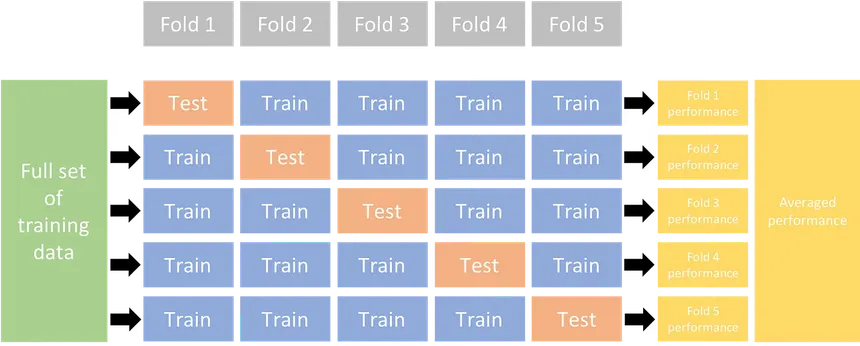

[RepeatedStratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html) refait ce découpage trois fois avec des tirages différents, soit quinze mesures au lieu de cinq. Il sert là où une **décision** se prend : quel modèle retenir, et à quel seuil. Avec une classe minoritaire peu nombreuse, un faible écart entre deux modèles peut n'être qu'un coup de dé ; trois répétitions réduisent ce risque.

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Quinze mesures au lieu de cinq, la ou une decision se prend
cv_fiable = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

lignes = []
for nom, modele in modeles.items():
    r = cross_validate(modele, X_train, y_train, cv=cv_fiable,
                       scoring=["f1", "roc_auc", "average_precision"])
    lignes.append({
        "modele": nom,
        "f1": round(r["test_f1"].mean(), 3),          # au seuil par defaut de 0.5
        "f1_ecart": round(r["test_f1"].std(), 3),
        "auc": round(r["test_roc_auc"].mean(), 3),
        "precision_moyenne": round(r["test_average_precision"].mean(), 3),
    })

comparaison = pl.DataFrame(lignes).sort("precision_moyenne", descending=True)
comparaison

modele,f1,f1_ecart,auc,precision_moyenne
str,f64,f64,f64,f64
"""super_learner""",0.049,0.024,0.793,0.299
"""logistique""",0.285,0.016,0.777,0.288
"""foret""",0.333,0.038,0.791,0.288
"""arbres_extra""",0.321,0.024,0.774,0.262
"""boosting""",0.323,0.024,0.773,0.259


***Résultats***

Trois mesures, trois lectures différentes.

- **Le F1** est calculé au seuil par défaut de 0,5. Avec 8 % de positifs, rien ne garantit que ce seuil soit le bon, et il pénalise lourdement un modèle dont les probabilités ne sont pas pondérées. À lire avec précaution.
- **L'AUC** juge le classement de tous les patients, positifs et négatifs confondus. Elle reste flatteuse quand la classe majoritaire domine.
- **La précision moyenne** juge le classement en se concentrant sur la classe rare. C'est la mesure la plus honnête à ce stade, et c'est elle qui sert de critère à l'optimisation de la section suivante.

La hiérarchie lue ici est provisoire : elle peut changer après le réglage du seuil, à la section 9.

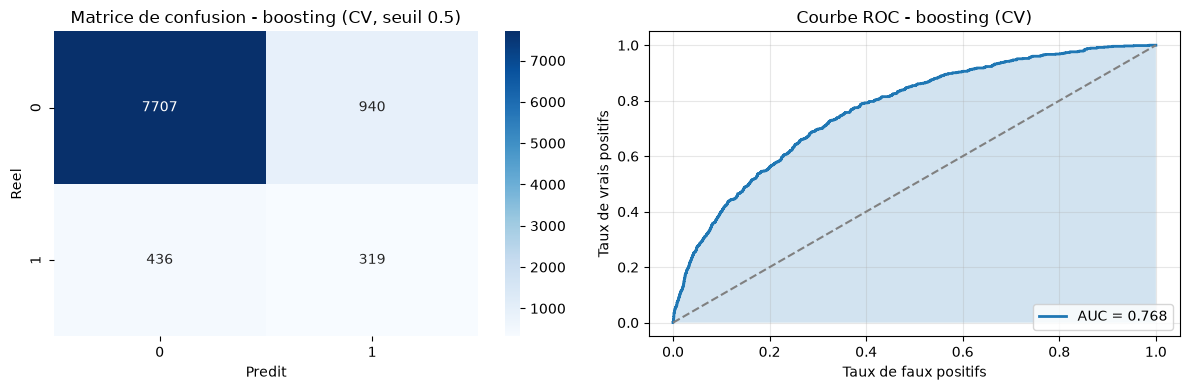

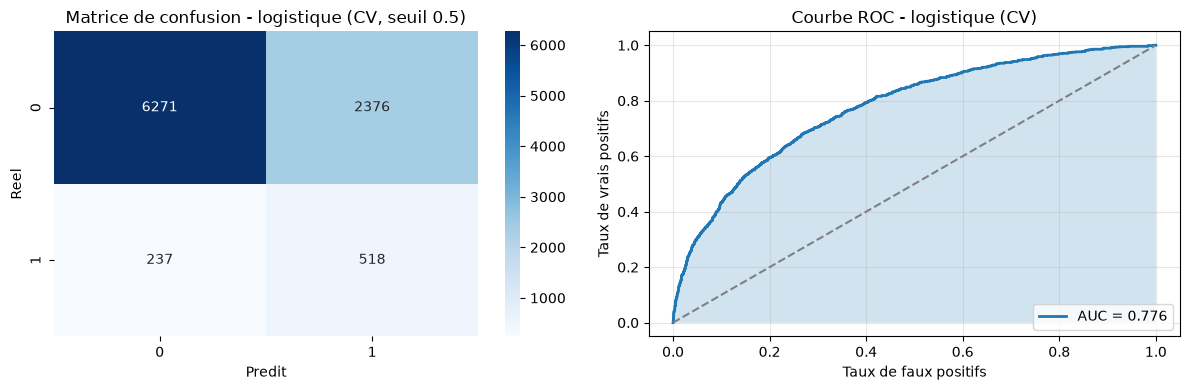

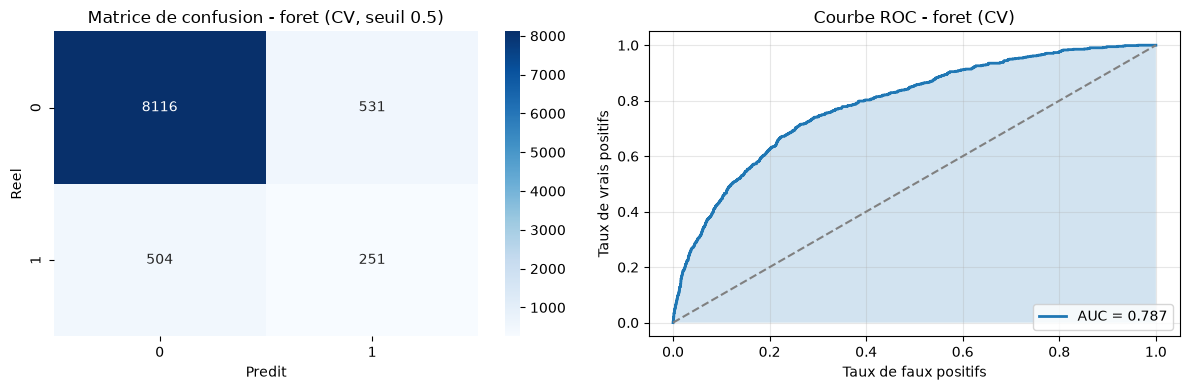

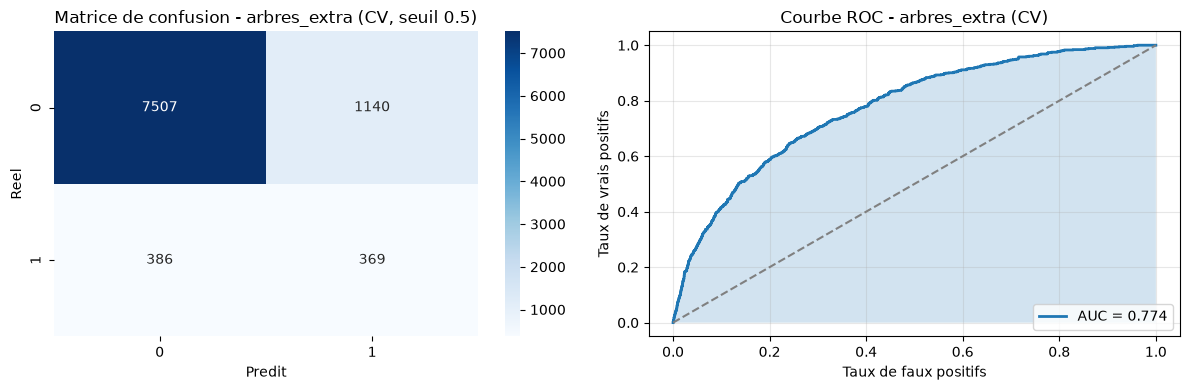

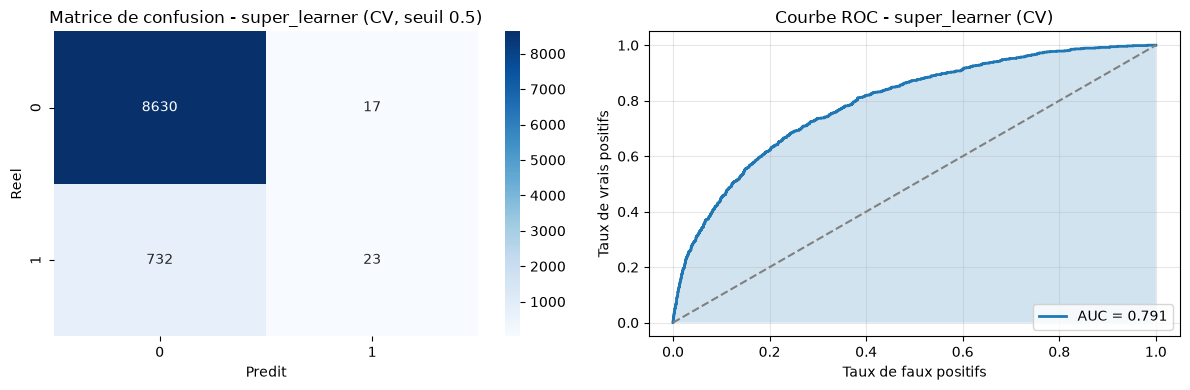

In [31]:
# Probabilites hors echantillon : un patient est predit par un modele qui ne l'a pas vu.
# Elles decrivent les modeles AVANT optimisation : la section 9 les recalculera
# sur les modeles regles.
proba_cv = {
    nom: cross_val_predict(modele, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    for nom, modele in modeles.items()
}

for nom, proba in proba_cv.items():
    y_pred = (proba >= 0.5).astype(int)          # sans optimisation : seuil par defaut

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matrice de confusion
    cm = confusion_matrix(y_train, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])

    axes[0].set_xlabel("Predit")
    axes[0].set_ylabel("Reel")
    axes[0].set_title(f"Matrice de confusion - {nom} (CV, seuil 0.5)")

    # Courbe ROC
    fpr, tpr, thresholds = roc_curve(y_train, proba)
    auc = roc_auc_score(y_train, proba)

    axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].fill_between(fpr, tpr, alpha=0.2)

    axes[1].set_xlabel("Taux de faux positifs")
    axes[1].set_ylabel("Taux de vrais positifs")
    axes[1].set_title(f"Courbe ROC - {nom} (CV)")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. Optimisation des hyperparamètres

Jusqu'ici les modèles tournent avec leurs réglages par défaut. On cherche maintenant les valeurs qui maximisent le F1, avant de régler le seuil de décision.

[BayesSearchCV](https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html) fait une **optimisation bayésienne** : au lieu de tirer des combinaisons au hasard, il apprend des essais précédents et vise les zones prometteuses. À budget égal il explore donc mieux qu'une recherche aléatoire.

`DeltaYStopper(delta=0.001)` arrête la recherche quand le score ne progresse plus.

Le super-learner n'est pas optimisé directement, ce serait beaucoup trop coûteux : il est reconstruit à partir des trois modèles de base une fois ceux-ci réglés.

**Dépendance à installer** : `uv add scikit-optimize`

***Les espaces de recherche***

In [32]:
# Les bornes sont volontairement larges : une valeur retenue collee a une borne
# signale un espace trop etroit. max_depth ne figure pas dans les deux forets,
# c'est min_samples_leaf qui y regularise reellement.
espaces = {
    "boosting": {
        "learning_rate": Real(1e-3, 0.3, prior="log-uniform"),
        "max_iter": Integer(200, 1500),
        "max_leaf_nodes": Integer(5, 127),
        "min_samples_leaf": Integer(10, 500),
        "l2_regularization": Real(1e-3, 1e5, prior="log-uniform"),
    },
    "logistique": {
        "modele__C": Real(1e-6, 1e2, prior="log-uniform"),
    },
    "arbres_extra": {
        "modele__n_estimators": Integer(200, 1200),
        "modele__min_samples_leaf": Integer(1, 120),
        "modele__max_features": Categorical(["sqrt", "log2"]),
    },
    "foret": {
        "modele__n_estimators": Integer(200, 1200),
        "modele__min_samples_leaf": Integer(1, 120),
        "modele__max_features": Categorical(["sqrt", "log2"]),
        "modele__class_weight": Categorical(["balanced", "balanced_subsample"]),
    },
}

***La recherche***

Le `StratifiedKFold` à cinq plis, pas le découpage répété : quarante candidats par modèle, la vitesse prime ici.

**Le critère est `average_precision`, pas le F1.** Le F1 se mesure à un seuil fixé d'avance, alors que le seuil n'est réglé qu'à la section 9. Optimiser des hyperparamètres au seuil par défaut reviendrait à juger les modèles sur une décision qui n'est pas encore prise. La précision moyenne, elle, juge le classement des patients indépendamment de tout seuil.

La recherche est longue. Elle n'est donc lancée **qu'une seule fois** : les hyperparamètres retenus sont enregistrés dans `models/hyperparametres_average_precision_v2.joblib`, et toute exécution ultérieure les relit. Le critère et la version de l'espace de recherche figurent dans le nom du fichier : en changer l'un ou l'autre invalide le cache tout seul.

`refit=False` : inutile de réentraîner ici, la section 9 le fera de toute façon.

In [33]:
# Le critere et la version de l'espace de recherche font partie du nom du cache :
# en changer l'un ou l'autre invalide le fichier precedent, sans suppression manuelle.
CRITERE = "average_precision"
VERSION = 3                       # bornes elargies, RobustScaler
CACHE = Path(f"../models/hyperparametres_{CRITERE}_v{VERSION}.joblib")

if CACHE.exists():
    trouve = joblib.load(CACHE)
    print("hyperparametres relus depuis", CACHE)
    print("supprimez ce fichier pour relancer une vraie recherche")
else:
    # n_jobs=-1 est sur la recherche, donc la foret passe a n_jobs=1 : sinon les deux
    # niveaux de parallelisme se disputent les coeurs et tout ralentit.
    foret.set_params(modele__n_jobs=1)

    trouve = {"params": {}, "resume": []}
    for nom, espace in espaces.items():
        recherche = BayesSearchCV(
            estimator=modeles[nom],
            search_spaces=espace,
            n_iter=40,
            scoring=CRITERE,
            cv=cv,
            refit=False,
            n_jobs=-1,
            random_state=SEED,
        )
        recherche.fit(X_train, y_train, callback=[DeltaYStopper(delta=0.001)])

        trouve["params"][nom] = dict(recherche.best_params_)
        # best_score_ suit CRITERE, donc on le compare a la precision moyenne de
        # la section 7 et non a son F1 : sinon les deux colonnes ne parlent pas
        # de la meme chose.
        trouve["resume"].append({
            "modele": nom,
            "ap_avant": comparaison.filter(pl.col("modele") == nom)["precision_moyenne"][0],
            "ap_apres": round(recherche.best_score_, 3),
            "essais": len(recherche.cv_results_["params"]),
        })
        print(nom, "->", dict(recherche.best_params_), flush=True)

    CACHE.parent.mkdir(exist_ok=True)
    joblib.dump(trouve, CACHE)

meilleurs = {nom: modeles[nom].set_params(**p) for nom, p in trouve["params"].items()}
pl.DataFrame(trouve["resume"])

hyperparametres relus depuis ..\models\hyperparametres_average_precision_v3.joblib
supprimez ce fichier pour relancer une vraie recherche


modele,ap_avant,ap_apres,essais
str,f64,f64,i64
"""boosting""",0.259,0.298,40
"""logistique""",0.288,0.297,21
"""arbres_extra""",0.262,0.263,40
"""foret""",0.288,0.29,40


***Le super-learner reconstruit***

Les quatre modèles réglés remplacent les modèles par défaut à l'intérieur de l'empilement, puis `modeles` est remplacé : tout ce qui suit travaille sur les modèles optimisés.

In [34]:
meilleurs["super_learner"] = StackingClassifier(
    estimators=[(nom, meilleurs[nom])
                for nom in ["boosting", "logistique", "foret", "arbres_extra"]],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=3,
    n_jobs=1,
)

modeles = meilleurs
print("modeles optimises :", list(modeles))

modeles optimises : ['boosting', 'logistique', 'arbres_extra', 'foret', 'super_learner']


## 9. Régler le seuil de décision

Un modèle renvoie une probabilité. Le passage à une décision 0 ou 1 se fait par un seuil, fixé par défaut à 0,5. Avec 8 % de positifs, ce choix n'a aucune raison d'être le bon.

[TunedThresholdClassifierCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html) cherche le seuil qui maximise le F1 **en validation croisée** : chaque patient sert à évaluer un modèle qui ne l'a pas vu à l'entraînement, sinon le seuil serait réglé sur des probabilités surajustées.

Son intérêt par rapport à une boucle écrite à la main : l'objet renvoyé **est lui-même un classifieur**, dont le `predict` applique déjà le seuil. Il n'y a donc plus de seuil à transporter jusqu'à `Predicts.py`, ni à réappliquer à la main.

`store_cv_results=True` conserve les scores essayés, ce qui permet de tracer la courbe juste après.

In [35]:
regles = {}
for nom, modele in modeles.items():
    regles[nom] = TunedThresholdClassifierCV(
        estimator=modele,
        scoring="f1",
        cv=cv_fiable,
        store_cv_results=True,   # garde la courbe F1 = f(seuil)
        n_jobs=-1,
    ).fit(X_train, y_train)

    print(nom, "-> seuil", round(regles[nom].best_threshold_, 3),
          "| F1", round(regles[nom].best_score_, 3), flush=True)

pl.DataFrame([
    {"modele": nom, "seuil_optimal": round(t.best_threshold_, 3),
     "f1_cv": round(t.best_score_, 3)}
    for nom, t in regles.items()
]).sort("f1_cv", descending=True)

boosting -> seuil 0.647 | F1 0.337
logistique -> seuil 0.649 | F1 0.334
arbres_extra -> seuil 0.263 | F1 0.324
foret -> seuil 0.527 | F1 0.341
super_learner -> seuil 0.193 | F1 0.352


modele,seuil_optimal,f1_cv
str,f64,f64
"""super_learner""",0.193,0.352
"""foret""",0.527,0.341
"""boosting""",0.647,0.337
"""logistique""",0.649,0.334
"""arbres_extra""",0.263,0.324


***Le F1 en fonction du seuil***

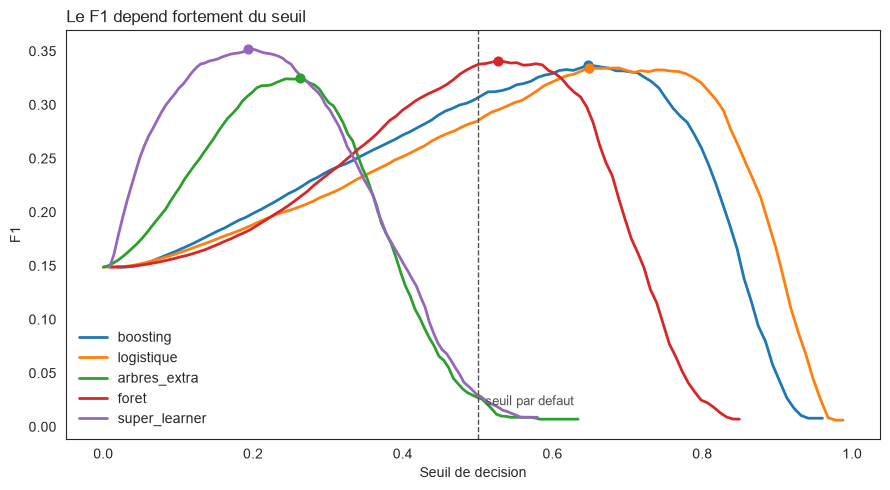

In [36]:
sns.set_style("white")

plt.figure(figsize=(9, 5))
for nom, t in regles.items():
    plt.plot(t.cv_results_["thresholds"], t.cv_results_["scores"], label=nom, linewidth=2)
    plt.scatter(t.best_threshold_, t.best_score_, s=40, zorder=5)

plt.axvline(0.5, color="#52514e", linestyle="--", linewidth=1)
plt.text(0.51, 0.02, "seuil par defaut", fontsize=9, color="#52514e")
plt.xlabel("Seuil de decision")
plt.ylabel("F1")
plt.title("Le F1 depend fortement du seuil", fontsize=12, loc="left")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

***Quelles variables portent la décision***

[permutation_importance](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html) mélange les valeurs d'une colonne au hasard et mesure de combien le score chute. Si rien ne bouge, le modèle ne s'en servait pas.

Son intérêt par rapport aux importances internes d'une forêt : elle fonctionne sur **n'importe quel modèle**, y compris le super-learner, et elle n'est pas biaisée en faveur des variables à nombreuses modalités.

Deux réserves à connaître. Le calcul est fait sur l'entraînement, le jeu de test restant intact jusqu'à la section suivante — une variable que le modèle surajuste peut donc paraître plus utile qu'elle ne l'est. Et deux variables redondantes se partagent le mérite : mélanger l'une laisse l'autre disponible, donc les deux semblent faibles alors que l'information, elle, compte.

In [37]:
# Le score utilise est la precision moyenne, comme pour l'optimisation :
# il ne depend d'aucun seuil.
nom_meilleur = max(regles, key=lambda n: regles[n].best_score_)

# .to_pandas() est indispensable : permutation_importance convertit en tableau
# numpy la colonne qu'il permute, et le ColumnTransformer, qui selectionne ses
# colonnes par leur nom, ne s'y retrouve plus. pandas arrive avec seaborn.
importances = permutation_importance(
    regles[nom_meilleur], X_train.to_pandas(), np.asarray(y_train),
    scoring="average_precision",
    n_repeats=5,
    max_samples=3000,        # borne le cout : le super-learner est lent a predire
    random_state=SEED,
    n_jobs=-1,
)

classement = pl.DataFrame({
    "variable": X_train.columns,
    "perte_moyenne": importances.importances_mean.round(4),
    "ecart": importances.importances_std.round(4),
}).sort("perte_moyenne", descending=True)

print("modele examine :", nom_meilleur)
classement.head(15)

c:\Users\Abdo\OneDrive\Desktop\Julian Gode\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


modele examine : super_learner


variable,perte_moyenne,ecart
str,f64,f64
"""GLU""",0.0793,0.0064
"""nb_anomalies""",0.0788,0.0036
"""AGE""",0.0734,0.009
"""SODIUM""",0.0598,0.0027
"""CHE""",0.0581,0.0022
"""BUN""",0.0487,0.005
"""LDH""",0.0481,0.0025
"""CRP""",0.0455,0.0032
"""MG""",0.0449,0.0026


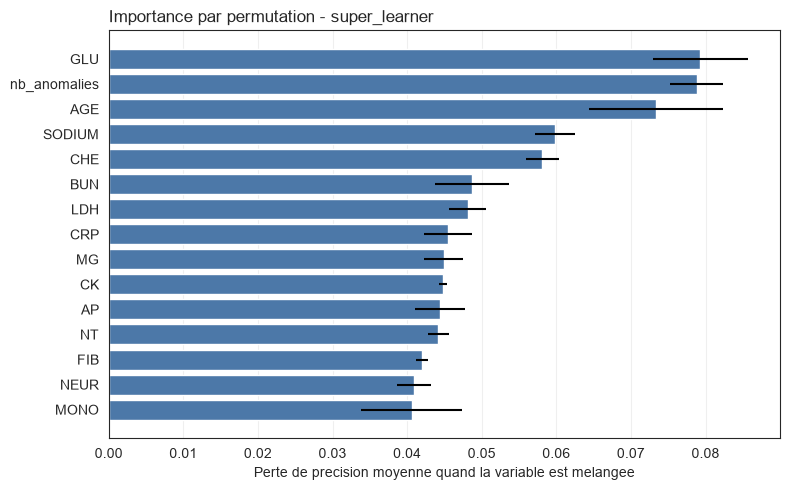

In [38]:
top = classement.head(15).reverse()

plt.figure(figsize=(8, 5))
plt.barh(top["variable"], top["perte_moyenne"], xerr=top["ecart"], color="#4c78a8")
plt.xlabel("Perte de precision moyenne quand la variable est melangee")
plt.title(f"Importance par permutation - {nom_meilleur}", fontsize=12, loc="left")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Évaluation finale sur le jeu de test

`TunedThresholdClassifierCV` a déjà réentraîné le modèle retenu sur tout l'entraînement, seuil compris. Il ne reste donc qu'à l'évaluer **une seule fois** sur le jeu de test.

C'est cette valeur qui estime la performance attendue le jour du rendu.

In [39]:
meilleur = max(regles, key=lambda n: regles[n].best_score_)
modele_final = regles[meilleur]          # deja entraine, seuil inclus
print("modele retenu :", meilleur, "| seuil :", round(modele_final.best_threshold_, 3))

pred_test = modele_final.predict(X_test)                    # le seuil est applique ici
proba_test = modele_final.predict_proba(X_test)[:, 1]

pl.DataFrame({
    "metrique": ["f1", "precision", "rappel", "auc"],
    "test": [
        round(f1_score(y_test, pred_test), 3),
        round(precision_score(y_test, pred_test), 3),
        round(recall_score(y_test, pred_test), 3),
        round(roc_auc_score(y_test, proba_test), 3),
    ],
})

modele retenu : super_learner | seuil : 0.193


metrique,test
str,f64
"""f1""",0.354
"""precision""",0.307
"""rappel""",0.418
"""auc""",0.773


                    precision    recall  f1-score   support

pas de bacteriemie       0.95      0.92      0.93      2162
       bacteriemie       0.31      0.42      0.35       189

          accuracy                           0.88      2351
         macro avg       0.63      0.67      0.64      2351
      weighted avg       0.90      0.88      0.89      2351



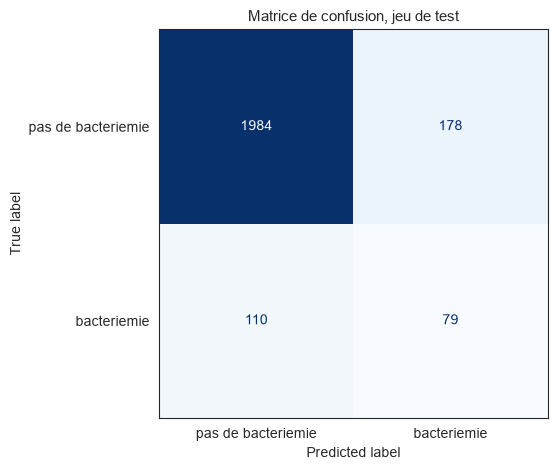

In [40]:
print(classification_report(y_test, pred_test, target_names=["pas de bacteriemie", "bacteriemie"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=["pas de bacteriemie", "bacteriemie"], colorbar=False, cmap="Blues"
)
plt.title("Matrice de confusion, jeu de test", fontsize=11)
plt.tight_layout()
plt.show()

***Où se placent les erreurs***

Les deux densités montrent comment le super-learner note les patients réellement négatifs et réellement positifs. Les points alignés sur l'axe sont les patients du jeu de test, séparés selon le quadrant de la matrice de confusion.

La ligne verticale est le seuil retenu : tout ce qui est à sa droite est prédit positif. Le recouvrement des deux densités montre du même coup pourquoi la précision reste modeste — aucun seuil ne peut les séparer proprement.

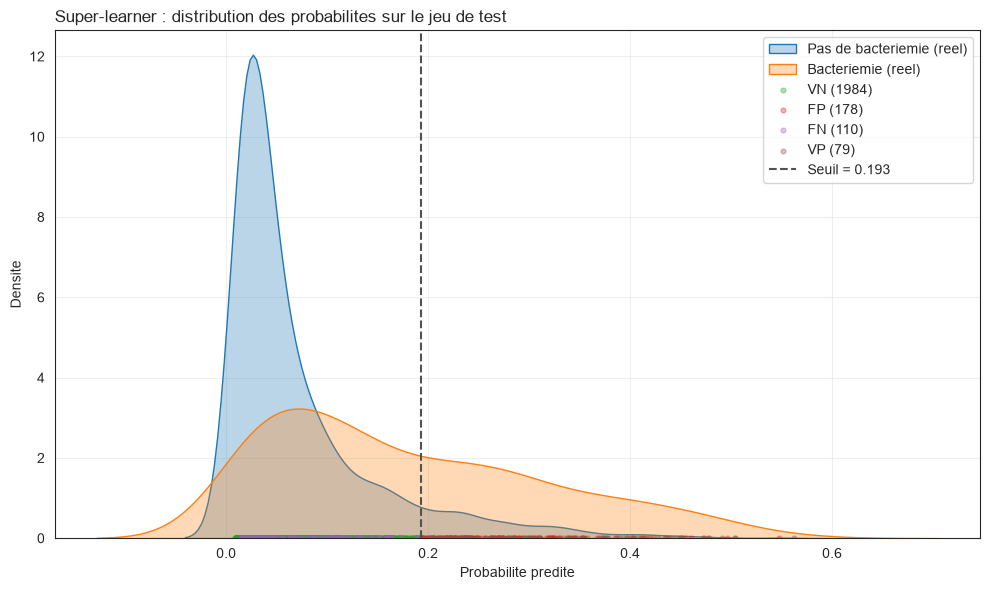

In [41]:
# Distribution des probabilites du super-learner sur le jeu de test
super_regle = regles["super_learner"]

proba_sl = super_regle.predict_proba(X_test)[:, 1]
pred_sl = super_regle.predict(X_test)
seuil_sl = super_regle.best_threshold_
y_vrai = np.asarray(y_test)

masques = {
    "VN": (y_vrai == 0) & (pred_sl == 0),
    "FP": (y_vrai == 0) & (pred_sl == 1),
    "FN": (y_vrai == 1) & (pred_sl == 0),
    "VP": (y_vrai == 1) & (pred_sl == 1),
}

plt.figure(figsize=(10, 6))

sns.kdeplot(proba_sl[y_vrai == 0], label="Pas de bacteriemie (reel)", fill=True, alpha=0.3)
sns.kdeplot(proba_sl[y_vrai == 1], label="Bacteriemie (reel)", fill=True, alpha=0.3)

for nom_masque, m in masques.items():
    plt.scatter(proba_sl[m], np.zeros(m.sum()), s=12, alpha=0.35,
                label=f"{nom_masque} ({m.sum()})")

plt.axvline(seuil_sl, linestyle="--", color="#52514e", label=f"Seuil = {seuil_sl:.3f}")

plt.xlabel("Probabilite predite")
plt.ylabel("Densite")
plt.title("Super-learner : distribution des probabilites sur le jeu de test",
          fontsize=12, loc="left")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

***Ce que montre le graphique***

Le **seuil** sépare les deux décisions : à sa gauche le modèle répond « pas de bactériémie », à sa droite « bactériémie ».

Les points alignés sur l'axe sont les patients du jeu de test, répartis selon leur situation :

| | Prédit « pas de bactériémie » | Prédit « bactériémie » |
|---|---|---|
| **Pas de bactériémie** | VN, vrais négatifs | FP, faux positifs |
| **Bactériémie** | FN, faux négatifs | VP, vrais positifs |

- Les **VN** sont massés sous le pic bleu : le modèle écarte bien les patients sans bactériémie.
- Les **FN** sont le vrai problème. La densité orange s'étale jusqu'aux probabilités les plus basses, donc beaucoup de bactériémies restent à gauche du seuil et ne sont pas détectées.
- Les **FP** et les **VP** se mélangent à droite du seuil, dans la zone où les deux densités se recouvrent.

**Déplacer le seuil ne fait que choisir son camp.** Vers la gauche, on récupère des VP, donc de la **sensibilité** — la part des bactériémies détectées, VP / (VP + FN) — mais on récupère aussi des FP, donc la précision baisse. Vers la droite, l'inverse. Le seuil retenu est celui qui maximise le F1, c'est-à-dire le meilleur compromis entre sensibilité et précision.

La queue qui descend sous zéro est un artefact du lissage de `kdeplot`, pas une probabilité négative.

## 11. Réentraînement et sauvegarde

Le modèle retenu est réentraîné sur **toutes** les données, entraînement et test réunis : plus de données, meilleur modèle. Le seuil est retrouvé au passage, par la même validation croisée, sur ce jeu complet.

`joblib` n'enregistre plus qu'un seul objet : le classifieur porte son seuil en lui, donc `Predicts.py` n'a qu'à appeler `predict`.

In [42]:
# X_tout = pl.concat([X_train, X_test])
# y_tout = np.concatenate([y_train, y_test])

# modele_final.fit(X_tout, y_tout)         # reentraine le modele et rejoue la recherche de seuil

# joblib.dump({"modele": modele_final, "colonnes": X_tout.columns},
#             "../models/modele_bacteriemie.joblib")

# print("enregistre : models/modele_bacteriemie.joblib",
#       "| seuil :", round(modele_final.best_threshold_, 3))

## 12. Prochaine étape : `Predicts.py`

Le script de rendu devra :

1. lire le fichier de test avec `null_values="NA"` ;
2. mettre `ID` de côté, et retirer `BloodCulture` si elle est présente ;
3. appliquer `preparer()`, identique à la section 3 ;
4. charger `models/modele_bacteriemie.joblib` et appeler `predict` : le seuil est déjà dans le modèle ;
5. écrire un CSV de deux colonnes, `ID` et `pred`, ne contenant que des 0 et des 1.

À tester sur le jeu de test interne privé de sa colonne cible, pour vérifier qu'il tourne sur un fichier de même structure que celui de l'enseignant.